<span style='font-size:50px; font-weight:bold;'>Model Building & Evaluation</span>

---

# Rating Prediction

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importing required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

<span style='font-size:22px; font-weight:500'>
    ➤ Load Data:
</span>

In [2]:
# load cleaned csv file
df = pd.read_csv('data/IMDb_movies_cleaned.csv')
df.head()

,title,genres,description,keywords,release_date,duration,content_rating,director,star_1,star_2,...,user_reviews,critic_reviews,watchlist_count,gross,budget,movie_url,category,currency_type,gross_usd,budget_usd
0,Kate & Leopold,Comedy|Fantasy|Romance,An English Duke from 1876 is inadvertently dra...,"time travel,time travel romance,female time tr...",2001-12-25,118,PG-13,James Mangold,Meg Ryan,Hugh Jackman,...,376.0,92.0,66600.0,"$76,019,048","$48,000,000 (estimated)",https://www.imdb.com/title/tt0035423/,Mid Rated,$,76019048.0,48000000.0
1,Ko to tamo peva,Adventure|Comedy|Drama,"It&apos;s April 5, 1941, somewhere in Serbia. ...","road trip,sex scene,female nudity,year 1941,yu...",1980-06-30,86,Unknown,Slobodan Sijan,Pavle Vuisic,Dragan Nikolic,...,42.0,11.0,12200.0,NaN,NaN,https://www.imdb.com/title/tt0076276/,Top Rated|Old Movies,NaN,NaN,NaN
2,Cannibal Holocaust,Adventure|Horror,An anthropologist ventures into the Amazon rai...,"rape,animal cruelty,gang rape,actual animal ki...",1985-06-21,95,Unrated,Ruggero Deodato,Robert Kerman,Francesca Ciardi,...,685.0,208.0,66800.0,$477,"$100,000 (estimated)",https://www.imdb.com/title/tt0078935/,Old Movies,$,477.0,100000.0
3,Saturn 3,Adventure|Horror|Sci-Fi,Two lovers stationed at a remote base in the a...,"psychopath,infatuation,robot sci fi,male rear ...",1980-02-15,88,R,Stanley Donen,Farrah Fawcett,Kirk Douglas,...,165.0,63.0,9300.0,"$9,000,000","£10,000,000 (estimated)",https://www.imdb.com/title/tt0079285/,Old Movies,£,9000000.0,12500000.0
4,Moskva slezam ne verit,Comedy|Drama|Romance,Three young provincial women come to Moscow in...,"city name in title,group of friends,soviet uni...",1980-02-11,150,PG,Vladimir Menshov,Vera Alentova,Aleksey Batalov,...,56.0,13.0,14600.0,$217,"$900,000 (estimated)",https://www.imdb.com/title/tt0079579/,Old Movies,$,217.0,900000.0


In [3]:
df.shape

(5637, 26)

In [4]:
df.isna().sum()

title                 0
genres                0
description           0
keywords            164
release_date          0
duration              0
content_rating        0
director              0
star_1                0
star_2                0
star_3                0
countries             0
languages             0
rating                0
metascore          1988
votes                 0
user_reviews          0
critic_reviews        0
watchlist_count       0
gross              1390
budget             1784
movie_url             0
category              0
currency_type      1784
gross_usd          1390
budget_usd         1787
dtype: int64

In [5]:
# converting obj to datetime and extracting year
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df['release_year'] = df['release_date'].dt.year

---

# Data Cleaning:

<span style='font-size:18px;'>
    ➤ Remove rows with missing values in gross_usd and budget_usd <br>
    ➤ Imputing metascore with the average of the median values of its genre’s metascore
</span>

In [6]:
df = df.dropna(subset=['gross_usd', 'budget_usd'])

In [7]:
df['keywords'] = df['keywords'].fillna('')
df = df[df['genres'] != 'Unknown']

In [8]:
df_genre = df.copy()
df_genre['genres'] = df['genres'].str.split("|")
df_genre = df_genre.explode('genres')

genre_metascore = df_genre.groupby('genres')['metascore'].median().astype(int)
genre_metascore

def calculate_avg_metascore(x):
    genres_list = str(x).split('|')
    scores = []
    
    for g in genres_list:
        if g in genre_metascore:
            scores.append(genre_metascore[g])
    
    # If no valid genre impute global median
    if len(scores) == 0:
        return df['metascore'].median()
    
    return sum(scores) / len(scores)

df['metascore_imputed'] = df['metascore'].copy()

mask = df['metascore'].isna()

df.loc[mask, 'metascore_imputed'] = df.loc[mask, 'genres'].apply(calculate_avg_metascore)
df['metascore'] = df['metascore_imputed']
df.drop(columns=['metascore_imputed'], inplace=True)

In [9]:
df.isna().sum()

title              0
genres             0
description        0
keywords           0
release_date       0
duration           0
content_rating     0
director           0
star_1             0
star_2             0
star_3             0
countries          0
languages          0
rating             0
metascore          0
votes              0
user_reviews       0
critic_reviews     0
watchlist_count    0
gross              0
budget             0
movie_url          0
category           0
currency_type      0
gross_usd          0
budget_usd         0
release_year       0
dtype: int64

In [10]:
df.shape

(3360, 27)

---

# Feature Engineering:

<span style='font-size:18px;'>➤ Reducing skewness in numerical columns with large values using `log transform` <br>
    ➤ Encoding Genres with `Multi-Label Binarizer` <br>
    ➤ Encoding Content Rating with `One-Hot Encode` <br>
    ➤ Calculating `Director Score` & `Star Score` using mean of their movies rating <br>
</span>

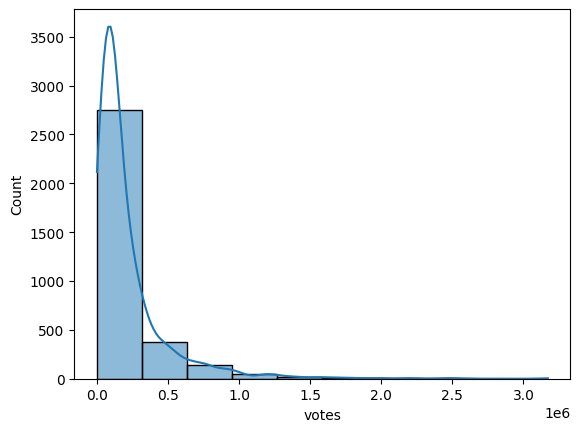

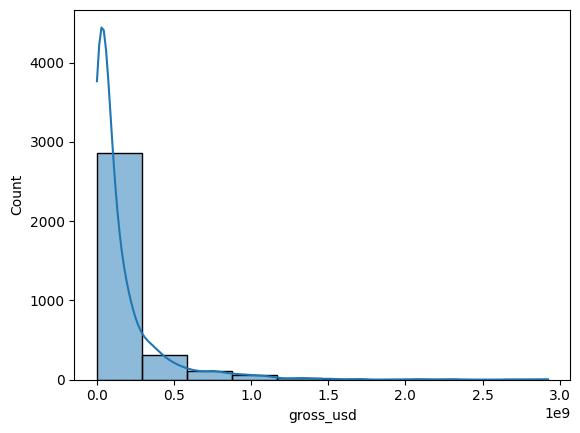

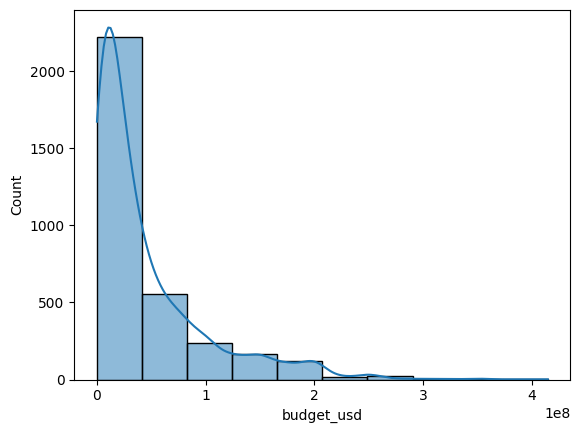

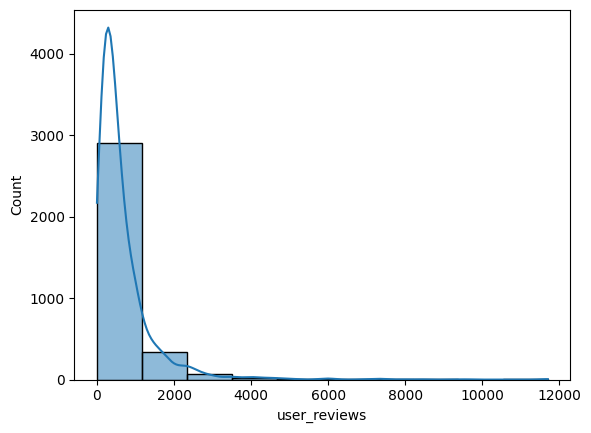

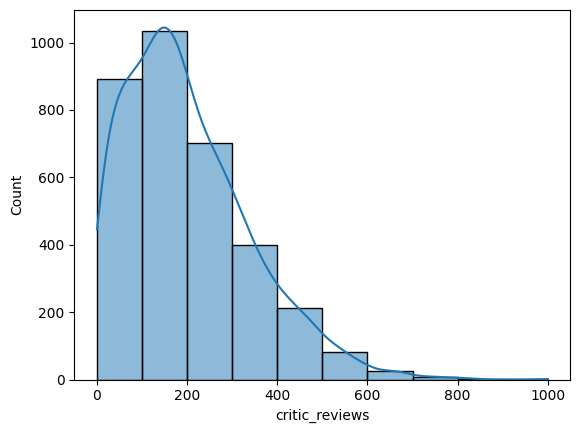

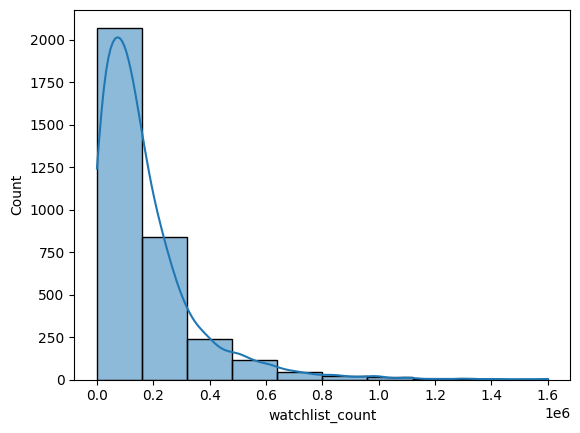

In [11]:
skew_cols = ['votes', 'gross_usd', 'budget_usd', 'user_reviews', 'critic_reviews', 'watchlist_count']
for col in skew_cols:
    sns.histplot(df[col], bins=10, kde=True)
    plt.show()

In [12]:
# Log Transform to handle skewness
df['log_votes'] = np.log1p(df['votes'])
df['log_gross'] = np.log1p(df['gross_usd'])
df['log_budget'] = np.log1p(df['budget_usd'])
df['log_user_reviews'] = np.log1p(df['user_reviews'])
df['log_critic_reviews'] = np.log1p(df['critic_reviews'])
df['log_watchlist_count'] = np.log1p(df['watchlist_count'])

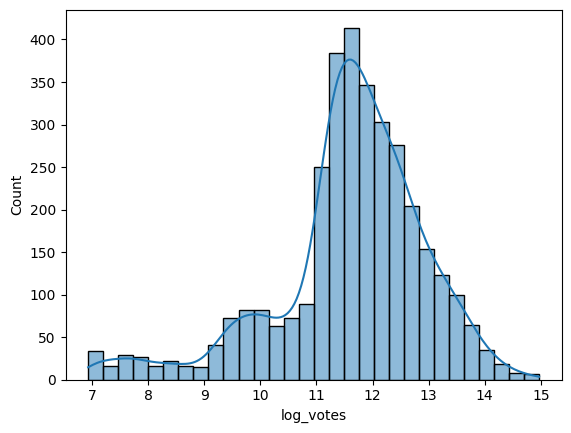

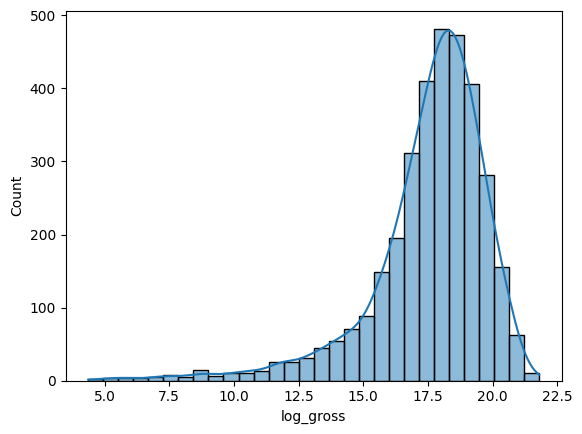

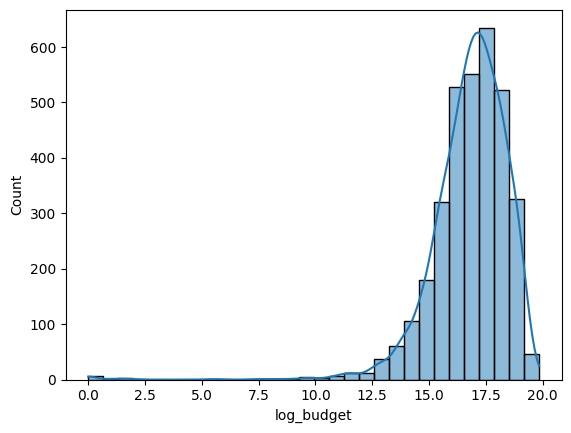

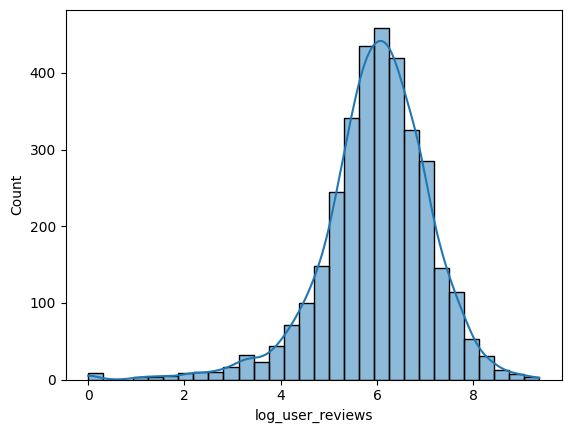

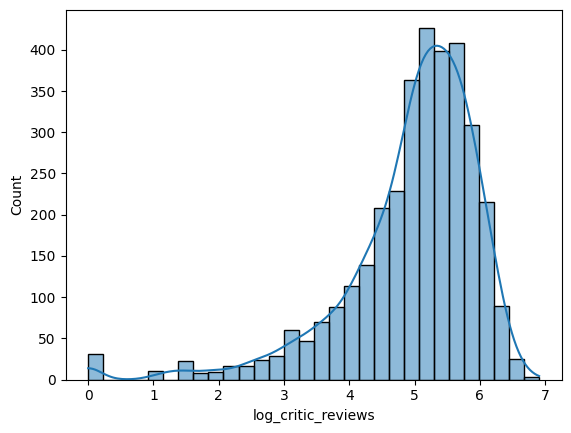

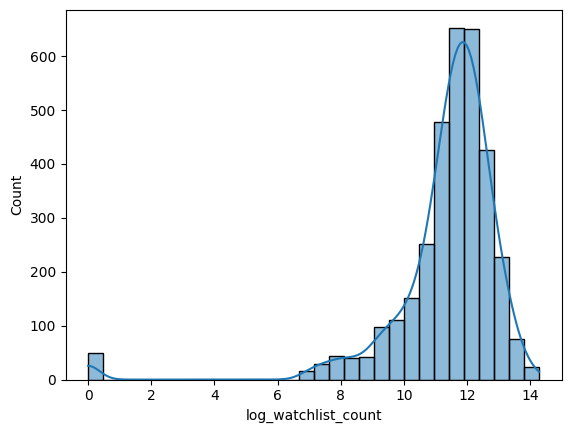

In [13]:
non_skew_cols = ['log_votes', 'log_gross', 'log_budget', 'log_user_reviews', 
                 'log_critic_reviews', 'log_watchlist_count']
for col in non_skew_cols:
    sns.histplot(df[col], bins=30, kde=True)
    plt.show()

In [14]:
# Genre Encoding using MultiLabelBinarizer
from sklearn.preprocessing import MultiLabelBinarizer

df['genres'] = df['genres'].str.split('|')

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['genres']),
    columns=mlb.classes_,
    index=df.index
)

df = pd.concat([df, genre_encoded], axis=1)

In [15]:
# Content Rating Encoding using One Hot Encoding
df = pd.get_dummies(df, columns=['content_rating'], drop_first=False)

In [16]:
# Director Encoding (Mean score)
director_mean = df.groupby('director')['rating'].mean()
df['director_score'] = df['director'].map(director_mean)

In [17]:
# Star Encoding (Mean score)
star_mean = df.groupby('star_1')['rating'].mean()
df['star_score'] = df['star_1'].map(star_mean)

In [18]:
df.head()

,title,genres,description,keywords,release_date,duration,director,star_1,star_2,star_3,...,content_rating_PG,content_rating_PG-13,content_rating_R,content_rating_TV-14,content_rating_TV-MA,content_rating_TV-PG,content_rating_Unknown,content_rating_Unrated,director_score,star_score
0,Kate & Leopold,"[Comedy, Fantasy, Romance]",An English Duke from 1876 is inadvertently dra...,"time travel,time travel romance,female time tr...",2001-12-25,118,James Mangold,Meg Ryan,Hugh Jackman,Liev Schreiber,...,False,True,False,False,False,False,False,False,7.21,6.4
2,Cannibal Holocaust,"[Adventure, Horror]",An anthropologist ventures into the Amazon rai...,"rape,animal cruelty,gang rape,actual animal ki...",1985-06-21,95,Ruggero Deodato,Robert Kerman,Francesca Ciardi,Perry Pirkanen,...,False,False,False,False,False,False,False,True,5.80,5.8
3,Saturn 3,"[Adventure, Horror, Sci-Fi]",Two lovers stationed at a remote base in the a...,"psychopath,infatuation,robot sci fi,male rear ...",1980-02-15,88,Stanley Donen,Farrah Fawcett,Kirk Douglas,Harvey Keitel,...,False,False,True,False,False,False,False,False,5.10,5.1
4,Moskva slezam ne verit,"[Comedy, Drama, Romance]",Three young provincial women come to Moscow in...,"city name in title,group of friends,soviet uni...",1980-02-11,150,Vladimir Menshov,Vera Alentova,Aleksey Batalov,Irina Muravyova,...,True,False,False,False,False,False,False,False,8.00,8.0
6,'Breaker' Morant,"[Drama, History, War]",Three Australian lieutenants are court martial...,"based on true story,1900s,19th century,boer,co...",1980-07-03,107,Bruce Beresford,Edward Woodward,Jack Thompson,John Waters,...,True,False,False,False,False,False,False,False,7.80,7.8


In [19]:
df.columns

Index(['title', 'genres', 'description', 'keywords', 'release_date',
       'duration', 'director', 'star_1', 'star_2', 'star_3', 'countries',
       'languages', 'rating', 'metascore', 'votes', 'user_reviews',
       'critic_reviews', 'watchlist_count', 'gross', 'budget', 'movie_url',
       'category', 'currency_type', 'gross_usd', 'budget_usd', 'release_year',
       'log_votes', 'log_gross', 'log_budget', 'log_user_reviews',
       'log_critic_reviews', 'log_watchlist_count', 'Action', 'Adventure',
       'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Musical', 'Mystery',
       'News', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western',
       'content_rating_G', 'content_rating_NC-17', 'content_rating_Not Rated',
       'content_rating_PG', 'content_rating_PG-13', 'content_rating_R',
       'content_rating_TV-14', 'content_rating_TV-MA', 'content_rating_TV-PG',
       'content_rating_Unknown'

---

<span style='font-size:22px; font-weight:500'>
    ➤ Feature Selection:
</span>

In [20]:
drop_cols = [
    'title', 'genres', 'votes', 'movie_url', 'currency_type', 'release_date', 'content_rating',
    'gross', 'budget', 'gross_usd', 'budget_usd', 'category',
    'director', 'star_1', 'star_2', 'star_3', 'description', 'keywords',
    'countries', 'languages', 'user_reviews', 'critic_reviews', 'watchlist_count'
]

df_model = df.drop(columns=drop_cols, errors='ignore')

In [21]:
len(df_model.columns)

45

<span style='font-size:22px; font-weight:500'>
    ➤ Outlier Treatment:
</span>

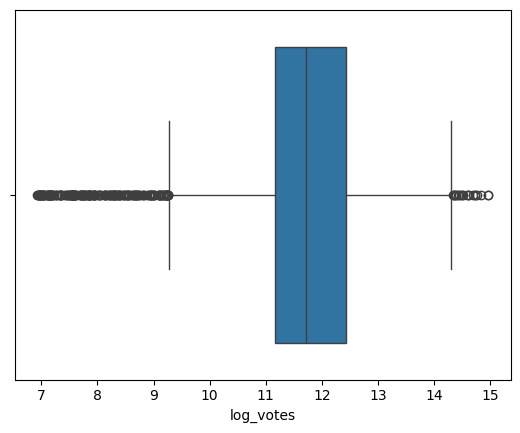

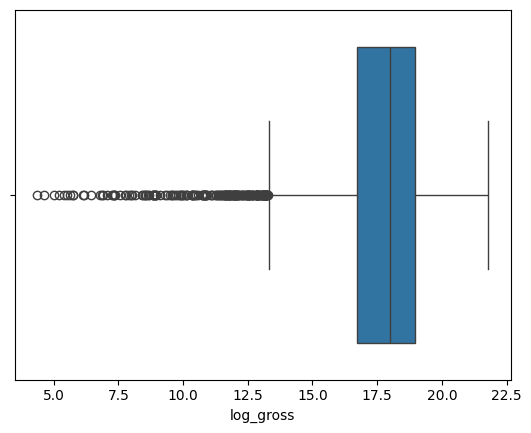

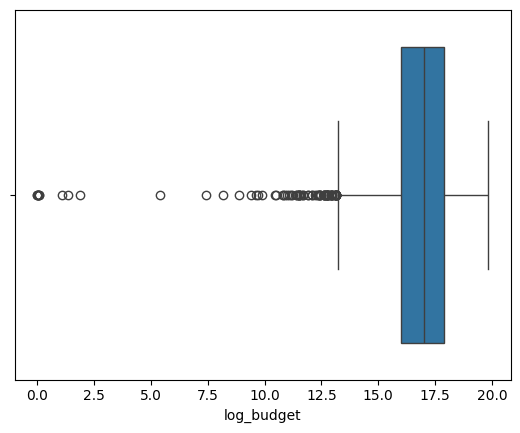

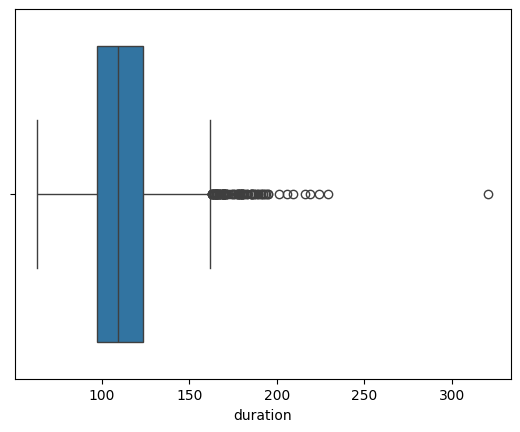

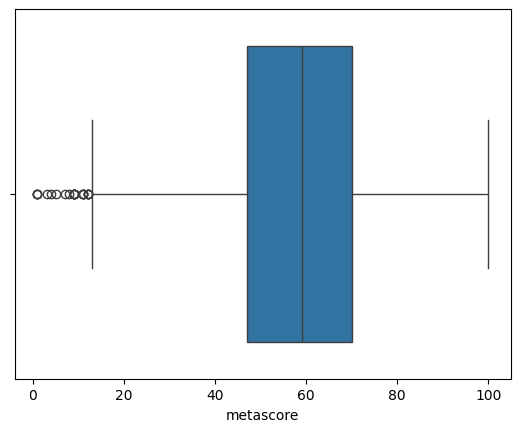

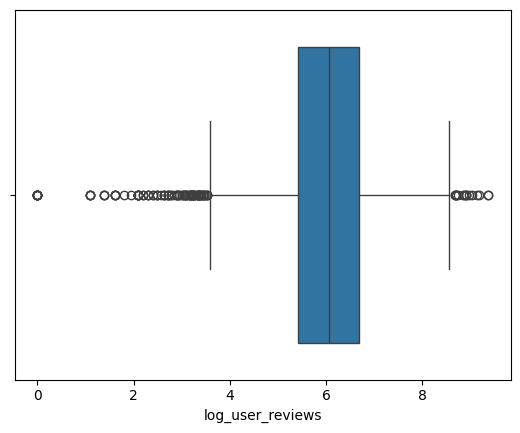

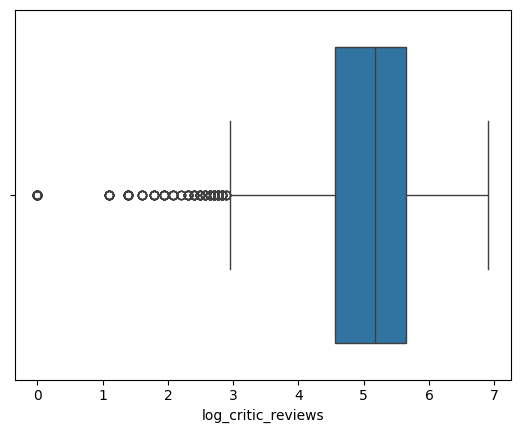

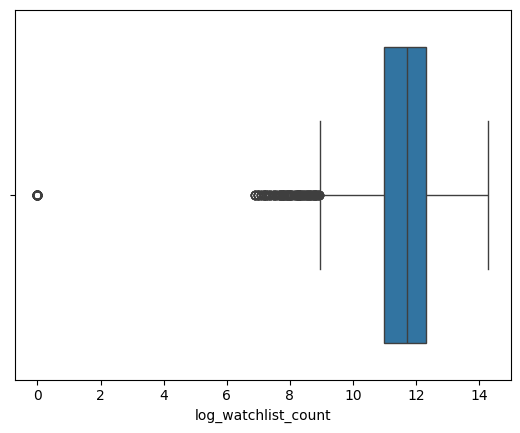

In [22]:
num_cols = ['log_votes', 'log_gross', 'log_budget', 'duration', 'metascore', 'log_user_reviews', 'log_critic_reviews', 'log_watchlist_count']
for i in num_cols:
    sns.boxplot(x=df_model[i])
    plt.show()

In [23]:
def outliers_treatment(x):
    x=x.clip(upper=x.quantile(0.98))
    x=x.clip(lower=x.quantile(0.02))
    return x

In [24]:
df_model[num_cols] = df_model[num_cols].apply(outliers_treatment)

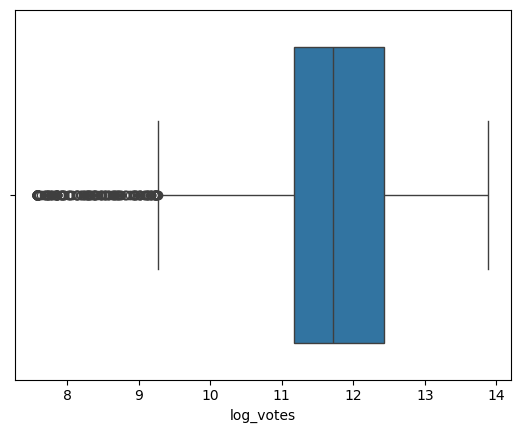

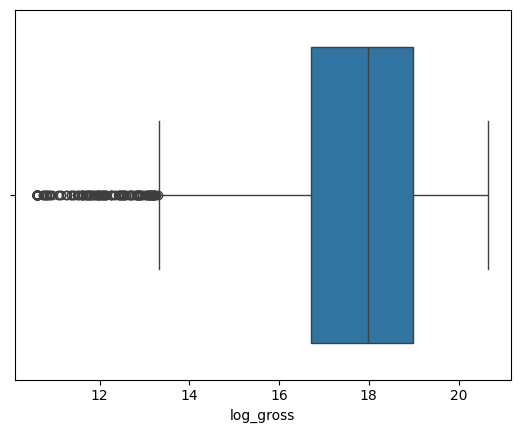

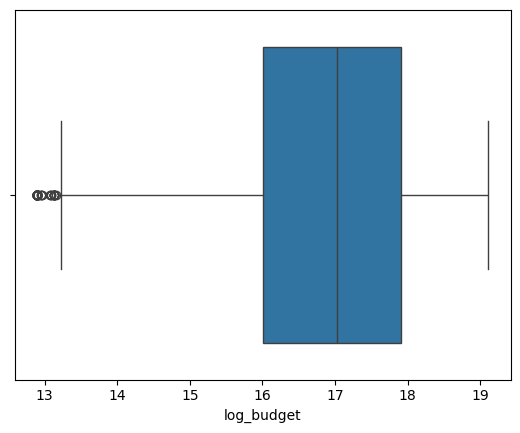

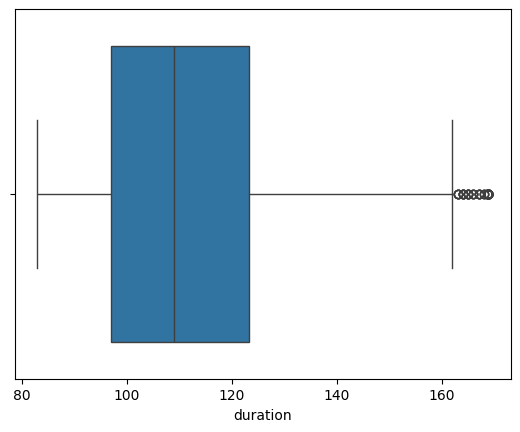

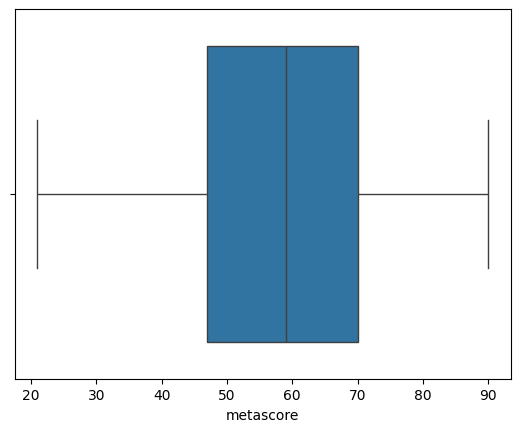

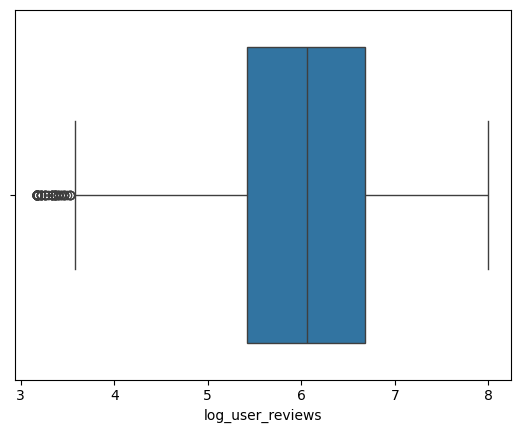

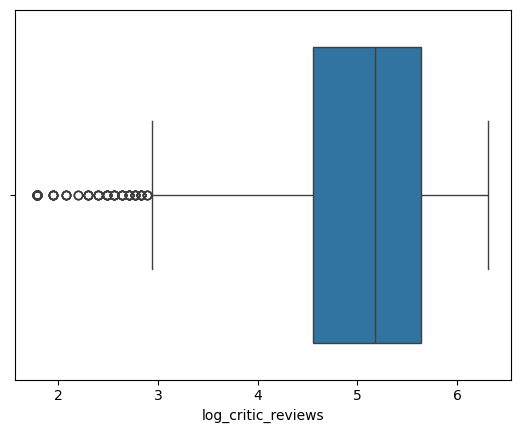

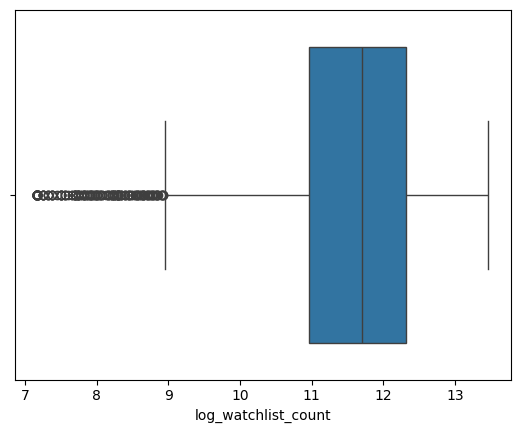

In [25]:
for i in num_cols:
    sns.boxplot(x=df_model[i])
    plt.show()

<span style='font-size:22px; font-weight:500'>
    ➤ Correlation Heatmap:
</span>

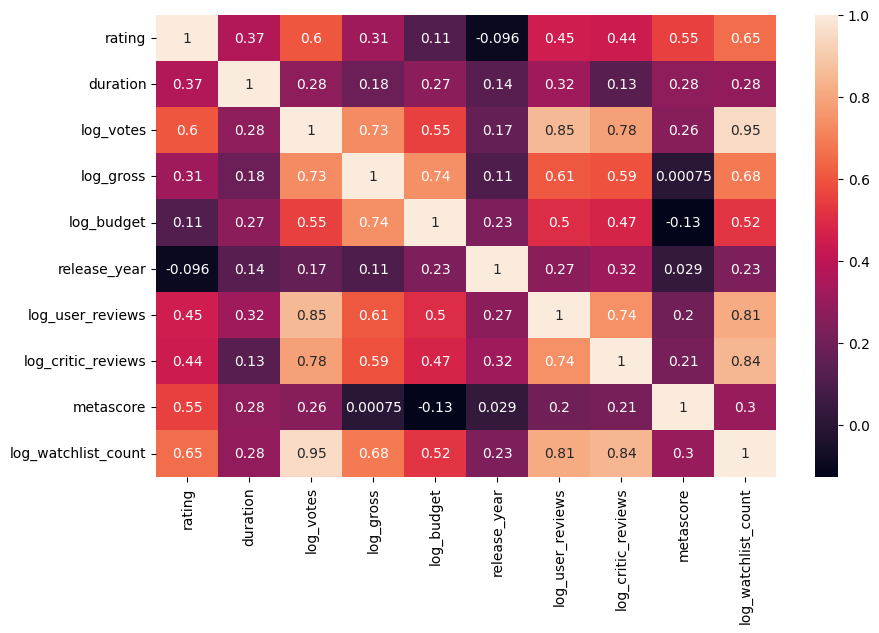

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df_model[['rating','duration','log_votes', 'log_gross', 'log_budget', 'release_year',
                     'log_user_reviews', 'log_critic_reviews', 'metascore', 'log_watchlist_count']].corr(), annot=True)
plt.show()

---

<span style='font-size:22px; font-weight:500'>
    ➤ Train Test Split & Scaling:
</span>

In [84]:
X = df_model.drop(columns=['rating'])
y = df_model['rating']

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [86]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
X.columns

Index(['duration', 'metascore', 'release_year', 'log_votes', 'log_gross',
       'log_budget', 'log_user_reviews', 'log_critic_reviews',
       'log_watchlist_count', 'Action', 'Adventure', 'Animation', 'Biography',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Romance',
       'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western', 'content_rating_G',
       'content_rating_NC-17', 'content_rating_Not Rated', 'content_rating_PG',
       'content_rating_PG-13', 'content_rating_R', 'content_rating_TV-14',
       'content_rating_TV-MA', 'content_rating_TV-PG',
       'content_rating_Unknown', 'content_rating_Unrated', 'director_score',
       'star_score'],
      dtype='object')

<span style='font-size:22px; font-weight:500'>
    ➤ Model Training using Hyperparameter Tuning:
</span>

In [88]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_lr_train = lr.predict(X_train)

In [89]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

In [90]:
# Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [8, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [91]:
import pprint

print("Best Parameters:") 
pprint.pprint(grid_search.best_params_, indent=4)
best_rf = grid_search.best_estimator_

Best Parameters:
{   'max_depth': 15,
    'max_features': 'sqrt',
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 200}


In [92]:
y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_rf_train = best_rf.predict(X_train_scaled)

<span style='font-size:22px; font-weight:500'>
    ➤ Model Evaluation:
</span>

In [93]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print("MSE:", round(mean_squared_error(y_true, y_pred),3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)),3))
    print("MAE:", round(mean_absolute_error(y_true, y_pred), 3))
    print("R2 Score:", round(r2_score(y_true, y_pred), 3))

In [94]:
print("------------Training Data------------")
evaluate_model("Linear Regression", y_train, y_pred_lr_train)
evaluate_model("Random Forest", y_train, y_pred_rf_train)

print("\n------------Testing Data------------")
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)

------------Training Data------------

Linear Regression Performance:
MSE: 0.132
RMSE: 0.363
MAE: 0.268
R2 Score: 0.92

Random Forest Performance:
MSE: 0.032
RMSE: 0.178
MAE: 0.133
R2 Score: 0.981

------------Testing Data------------

Linear Regression Performance:
MSE: 0.135
RMSE: 0.367
MAE: 0.276
R2 Score: 0.912

Random Forest Performance:
MSE: 0.144
RMSE: 0.379
MAE: 0.278
R2 Score: 0.907


<span style='font-size:22px; font-weight:500'>
    ➤ Feature Importance:
</span>

In [95]:
# exploring important features
importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))


Top 10 Important Features:
director_score         0.264689
star_score             0.192280
log_watchlist_count    0.116541
metascore              0.108590
log_votes              0.079246
log_critic_reviews     0.039555
log_user_reviews       0.038092
duration               0.028518
log_gross              0.024189
Drama                  0.020010
dtype: float64


---

# Testing New Data

<span style='font-size:18px;'>
    ➤ Testing the both models using new unseen data (2025-26 movies)
</span>

In [63]:
new_df = pd.read_csv("data/IMDb_test_movies_cleaned.csv")
new_df.head()

,title,genres,description,keywords,release_date,duration,content_rating,director,star_1,star_2,...,votes,user_reviews,critic_reviews,watchlist_count,gross,budget,movie_url,category,gross_usd,budget_usd
0,Nezha: Mo tong nao hai,Animation|Action|Adventure,"After a great catastrophe, the souls of Nezha ...","sequel,coco cartoon animated film,chinese folk...",2025-01-29,144,PG-13,Yu Yang,Yanting Lü,Joseph,...,23795,330.0,115.0,43800.0,"$2,260,176,370","$80,000,000 (estimated)",https://www.imdb.com/title/tt34956443/,New Movies,2.260176e+09,80000000.0
1,Him,Horror|Sport,A young athlete descends into a world of terro...,"american football sport,male rear nudity,male ...",2025-09-19,96,R,Justin Tipping,Marlon Wayans,Tyriq Withers,...,22039,381.0,139.0,46500.0,"$27,834,512","$27,000,000 (estimated)",https://www.imdb.com/title/tt20990442/,New Movies,2.783451e+07,27000000.0
2,They Will Kill You,Action|Comedy|Horror,A woman takes a job as a housekeeper in a NYC ...,"one person army action,splatter horror,occult ...",2026-03-27,94,R,Kirill Sokolov,Zazie Beetz,Myha&apos;la,...,5565,118.0,107.0,44000.0,"$10,421,707","$20,000,000 (estimated)",https://www.imdb.com/title/tt31728330/,New Movies,1.042171e+07,20000000.0
3,Return to Silent Hill,Drama|Horror|Mystery,When a man receives a mysterious letter from h...,"based on video game,male protagonist,psycholog...",2026-01-23,106,R,Christophe Gans,Jeremy Irvine,Hannah Emily Anderson,...,16572,469.0,98.0,48000.0,"$47,650,944","$23,000,000 (estimated)",https://www.imdb.com/title/tt22868010/,New Movies,4.765094e+07,23000000.0
4,One of Them Days,Comedy,When best friends and roommates Dreux and Alys...,"blood,african american,gun,los angeles califor...",2025-01-17,97,R,Lawrence Lamont,Keke Palmer,SZA,...,19176,126.0,73.0,31600.0,"$51,896,264","$14,000,000 (estimated)",https://www.imdb.com/title/tt32221196/,New Movies,5.189626e+07,14000000.0


In [64]:
new_df.shape

(128, 25)

In [65]:
new_df.isna().sum()

title              0
genres             0
description        0
keywords           0
release_date       0
duration           0
content_rating     0
director           0
star_1             0
star_2             0
star_3             0
countries          0
languages          0
rating             0
metascore          0
votes              0
user_reviews       0
critic_reviews     0
watchlist_count    0
gross              0
budget             0
movie_url          0
category           0
gross_usd          0
budget_usd         0
dtype: int64

In [66]:
new_df["release_date"] = pd.to_datetime(new_df["release_date"], errors="coerce")

In [67]:
new_df['release_year'] = new_df['release_date'].dt.year

In [68]:
# Log transforms
new_df['log_votes'] = np.log1p(new_df['votes'])
new_df['log_gross'] = np.log1p(new_df['gross_usd'])
new_df['log_budget'] = np.log1p(new_df['budget_usd'])
new_df['log_user_reviews'] = np.log1p(new_df['user_reviews'])
new_df['log_critic_reviews'] = np.log1p(new_df['critic_reviews'])
new_df['log_watchlist_count'] = np.log1p(new_df['watchlist_count'])

In [69]:
new_df['genres'] = new_df['genres'].str.split('|')

mlb = MultiLabelBinarizer()
new_genre_encoded = pd.DataFrame(
    mlb.fit_transform(new_df['genres']),
    columns=mlb.classes_,
    index=new_df.index
)

new_df = pd.concat([new_df, new_genre_encoded], axis=1)

In [70]:
new_df = pd.get_dummies(new_df, columns=['content_rating'])

In [71]:
new_df['director_score'] = new_df['director'].map(director_mean)
new_df['star_score'] = new_df['star_1'].map(star_mean)

# Handle unseen values
global_mean = df['director_score'].mean()

new_df['director_score'] = new_df['director_score'].fillna(global_mean)
new_df['star_score'] = new_df['star_score'].fillna(global_mean)

In [72]:
new_df.columns

Index(['title', 'genres', 'description', 'keywords', 'release_date',
       'duration', 'director', 'star_1', 'star_2', 'star_3', 'countries',
       'languages', 'rating', 'metascore', 'votes', 'user_reviews',
       'critic_reviews', 'watchlist_count', 'gross', 'budget', 'movie_url',
       'category', 'gross_usd', 'budget_usd', 'release_year', 'log_votes',
       'log_gross', 'log_budget', 'log_user_reviews', 'log_critic_reviews',
       'log_watchlist_count', 'Action', 'Adventure', 'Animation', 'Biography',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Sci-Fi', 'Sport',
       'Thriller', 'War', 'Western', 'content_rating_G',
       'content_rating_Not Rated', 'content_rating_PG', 'content_rating_PG-13',
       'content_rating_R', 'director_score', 'star_score'],
      dtype='object')

In [73]:
new_df = new_df.drop(columns=[
    'genres', 'content_rating', 'release_date', 'gross', 'budget',
    'director', 'star_1', 'star_2', 'star_3', 'description', 'keywords',
    'votes', 'gross_usd', 'budget_usd', 'watchlist_count', 'user_reviews', 'critic_reviews'
], errors='ignore')

In [74]:
new_df.isna().sum()

title                       0
duration                    0
countries                   0
languages                   0
rating                      0
metascore                   0
movie_url                   0
category                    0
release_year                0
log_votes                   0
log_gross                   0
log_budget                  0
log_user_reviews            0
log_critic_reviews          0
log_watchlist_count         0
Action                      0
Adventure                   0
Animation                   0
Biography                   0
Comedy                      0
Crime                       0
Documentary                 0
Drama                       0
Family                      0
Fantasy                     0
History                     0
Horror                      0
Music                       0
Mystery                     0
Romance                     0
Sci-Fi                      0
Sport                       0
Thriller                    0
War       

In [75]:
X_new = new_df.drop(columns=['rating'])

X_new = X_new.reindex(columns=X.columns, fill_value=0)

In [76]:
X.columns

Index(['duration', 'metascore', 'release_year', 'log_votes', 'log_gross',
       'log_budget', 'log_user_reviews', 'log_critic_reviews',
       'log_watchlist_count', 'Action', 'Adventure', 'Animation', 'Biography',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Romance',
       'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western', 'content_rating_G',
       'content_rating_NC-17', 'content_rating_Not Rated', 'content_rating_PG',
       'content_rating_PG-13', 'content_rating_R', 'content_rating_TV-14',
       'content_rating_TV-MA', 'content_rating_TV-PG',
       'content_rating_Unknown', 'content_rating_Unrated', 'director_score',
       'star_score'],
      dtype='object')

In [77]:
X_new.columns

Index(['duration', 'metascore', 'release_year', 'log_votes', 'log_gross',
       'log_budget', 'log_user_reviews', 'log_critic_reviews',
       'log_watchlist_count', 'Action', 'Adventure', 'Animation', 'Biography',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Romance',
       'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western', 'content_rating_G',
       'content_rating_NC-17', 'content_rating_Not Rated', 'content_rating_PG',
       'content_rating_PG-13', 'content_rating_R', 'content_rating_TV-14',
       'content_rating_TV-MA', 'content_rating_TV-PG',
       'content_rating_Unknown', 'content_rating_Unrated', 'director_score',
       'star_score'],
      dtype='object')

In [78]:
Y_new = new_df['rating']

In [79]:
X_new_scaled = scaler.transform(X_new)

In [80]:
X_new_scaled.shape

(128, 44)

In [81]:
Y_new_pred_lr = lr.predict(X_new)
evaluate_model("Linear Regression:", Y_new, Y_new_pred_lr)


Linear Regression: Performance:
MSE: 0.683
RMSE: 0.826
MAE: 0.539
R2 Score: 0.36


In [82]:
Y_new_pred_rf = best_rf.predict(X_new_scaled)

In [83]:
print("------------New Unseen Data------------")
evaluate_model("Random Forest", Y_new, Y_new_pred_rf)

------------New Unseen Data------------

Random Forest Performance:
MSE: 0.705
RMSE: 0.839
MAE: 0.546
R2 Score: 0.34


---

# Insights

<span style='font-size:18px;'>
    ➤ Both models give very less score and high error <br>
    ➤ This means both models has been overfitted, they've memorized the data <br>
    ➤ As we've unbalanced dataset, and not much features, our models failed to predict on new data <br>
    ➤ Also, movies rating are dependent on many external factors, even advanced models cannont perfectly predict the ratings without user behavior data. 
</span>

---